In [1]:
import pandas as pd

In [2]:
path_004 = 'test.csv' 
df_multiclass_test = pd.read_csv(path_004)
df_multiclass_test

,index,text
0,0,Очень хороший магазин и сотрудники приятный
1,1,"Самый обычный продуктовый магазин. Есть сыры,..."
2,2,Всё хорошо и комфортно
3,3,"Маленький филиальчик, все необходимое есть. Дв..."
4,4,Плохо относятся к клиентам!!!!!\n
...,...,...
12162,12162,Персонал вежливый . Большой ассортимент
12163,12163,Скидки на сыры. Скидки на алкоголь. Приемлимые...
12164,12164,"Рядом с домом, неплохая пятерочка, персонал хо..."
12165,12165,Хороший магазин у дома. Кассиры приветливые. П...


In [3]:
length_counts = df_multiclass_test['text'].astype(str).str.len().value_counts().reset_index()
length_counts.columns = ['Длина значения', 'Количество строк']
length_counts = length_counts.sort_values('Длина значения').reset_index(drop=True)

print(length_counts)

     Длина значения  Количество строк
0                 1                 1
1                 2                12
2                 3                 3
3                 4                20
4                 5                25
..              ...               ...
705            1686                 1
706            1799                 1
707            1958                 1
708            2000                 1
709            3171                 1

[710 rows x 2 columns]


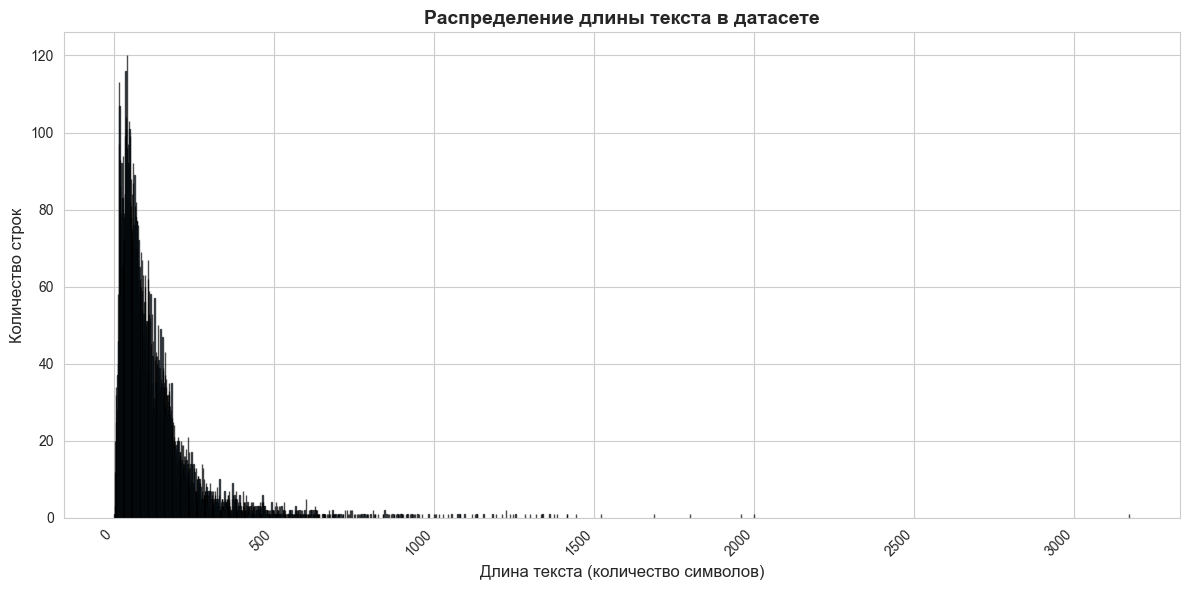

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Столбчатая диаграмма
plt.bar(length_counts['Длина значения'], 
        length_counts['Количество строк'], 
        color='steelblue', 
        edgecolor='black',
        alpha=0.7)

plt.xlabel('Длина текста (количество символов)', fontsize=12)
plt.ylabel('Количество строк', fontsize=12)
plt.title('Распределение длины текста в датасете', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
length_counts = df_multiclass_test['text'].astype(str).str.len().value_counts().reset_index()
length_counts.columns = ['Длина значения', 'Количество строк']
length_counts = length_counts.sort_values('Длина значения').reset_index(drop=True)

# Разбиение на 4 группы с диапазонами
length_counts['Квартиль'] = pd.qcut(length_counts['Длина значения'], q=4, precision=0)
length_counts_grouped = length_counts.groupby('Квартиль', observed=False)['Количество строк'].sum().reset_index()
length_counts_grouped.columns = ['Диапазон длины', 'Количество строк']

In [10]:
length_counts_grouped

,Диапазон длины,Количество строк
0,"(0.0, 178.0]",9847
1,"(178.0, 356.0]",1684
2,"(356.0, 566.0]",424
3,"(566.0, 3171.0]",212


In [13]:
path_003 = 'train.csv' #  'sample_submission.csv.csv'
df_multiclass_train = pd.read_csv(path_003)
df_multiclass_train

,rate,text
0,4,Очень понравилось. Были в начале марта с соба...
1,5,В целом магазин устраивает.\nАссортимент позво...
2,5,"Очень хорошо что открылась 5 ка, теперь не над..."
3,3,Пятёрочка громко объявила о том как она заботи...
4,3,"Тесно, вечная сутолока, между рядами трудно ра..."
...,...,...
48660,5,"Удобный, но маленький и ещё не обновили как др..."
48661,2,"Постоянно обман в цене,написанна сумма на акци..."
48662,2,Очень хочется пожелать этому магазину стать та...
48663,5,"Нравится ваш магазин, персонал одекватный, пор..."


In [15]:
length_counts_train = df_multiclass_train['text'].astype(str).str.len().value_counts().reset_index()
length_counts_train.columns = ['Длина значения', 'Количество строк']
length_counts_train = length_counts_train.sort_values('Длина значения').reset_index(drop=True)

# Разбиение на 4 группы с диапазонами
length_counts_train['Квартиль'] = pd.qcut(length_counts_train['Длина значения'], q=4, precision=0)
length_counts_grouped_train = length_counts_train.groupby('Квартиль', observed=False)['Количество строк'].sum().reset_index()
length_counts_grouped_train.columns = ['Диапазон длины', 'Количество строк']


length_counts_grouped_train

,Диапазон длины,Количество строк
0,"(1.0, 251.0]",43651
1,"(251.0, 500.0]",3934
2,"(500.0, 788.0]",758
3,"(788.0, 3965.0]",322


In [6]:
df_multiclass_train.describe()

,rate
count,48665.000000
mean,4.055666
std,1.273523
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


In [7]:
df_multiclass_train['rate'].value_counts()

rate
5    26069
4     9922
3     6126
1     4138
2     2410
Name: count, dtype: int64

In [16]:
# Создаем столбец с длиной текста и определяем квартили
df_multiclass_train['text_length'] = df_multiclass_train['text'].astype(str).str.len()
df_multiclass_train['Квартиль_длины'] = pd.qcut(df_multiclass_train['text_length'], q=4, labels=['Q1 (короткие)', 'Q2', 'Q3', 'Q4 (длинные)'])

# Анализ зависимости rate от квартиля длины
rate_by_quartile = df_multiclass_train.groupby('Квартиль_длины', observed=False)['rate'].agg(['mean', 'median', 'std', 'count']).round(2)
print(rate_by_quartile)

                mean  median   std  count
Квартиль_длины                           
Q1 (короткие)   4.36     5.0  1.07  12182
Q2              4.24     5.0  1.11  12152
Q3              4.06     5.0  1.24  12292
Q4 (длинные)    3.55     4.0  1.48  12039
